In [1]:
!mkdir -p model

# Download prototxt
!wget https://raw.githubusercontent.com/richzhang/colorization/caffe/colorization/models/colorization_deploy_v2.prototxt -O model/colorization_deploy_v2.prototxt

# Download points file
!wget https://raw.githubusercontent.com/richzhang/colorization/caffe/colorization/resources/pts_in_hull.npy -O model/pts_in_hull.npy

# Download Caffe model
!wget "https://www.dropbox.com/s/dx0qvhhp5hbcx7z/colorization_release_v2.caffemodel?dl=1" -O model/colorization_release_v2.caffemodel


--2025-04-23 15:36:40--  https://raw.githubusercontent.com/richzhang/colorization/caffe/colorization/models/colorization_deploy_v2.prototxt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9945 (9.7K) [text/plain]
Saving to: ‘model/colorization_deploy_v2.prototxt’

model/colorization_ 100%[===================>]   9.71K  --.-KB/s    in 0.001s  

2025-04-23 15:36:40 (12.5 MB/s) - ‘model/colorization_deploy_v2.prototxt’ saved [9945/9945]

--2025-04-23 15:36:40--  https://raw.githubusercontent.com/richzhang/colorization/caffe/colorization/resources/pts_in_hull.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.

In [2]:
from google.colab import files
uploaded = files.upload()


Saving tiger.jpg to tiger.jpg


Loading model...


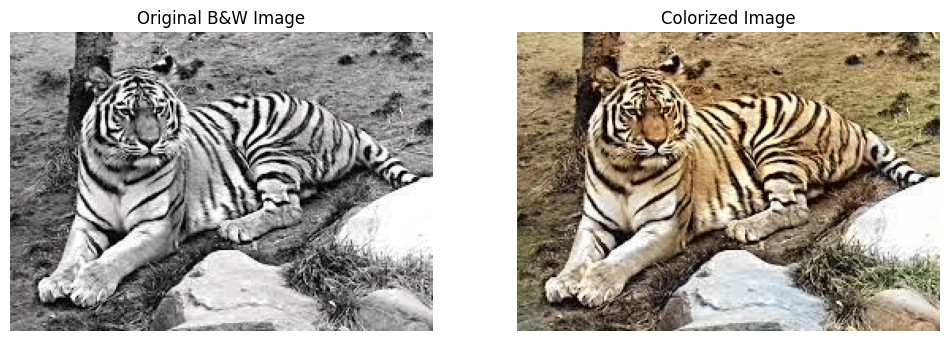

In [3]:
import numpy as np
import cv2
import os
from matplotlib import pyplot as plt

# Load model files
PROTOTXT = "model/colorization_deploy_v2.prototxt"
POINTS = "model/pts_in_hull.npy"
MODEL = "model/colorization_release_v2.caffemodel"
IMAGE_PATH = "tiger.jpg"  # <-- Change to your uploaded file name

# Load the model
print("Loading model...")
net = cv2.dnn.readNetFromCaffe(PROTOTXT, MODEL)
pts = np.load(POINTS)

class8 = net.getLayerId("class8_ab")
conv8 = net.getLayerId("conv8_313_rh")
pts = pts.transpose().reshape(2, 313, 1, 1)
net.getLayer(class8).blobs = [pts.astype("float32")]
net.getLayer(conv8).blobs = [np.full([1, 313], 2.606, dtype="float32")]

# Load the image
image = cv2.imread(IMAGE_PATH)
if image is None:
    raise Exception(f"Image not found at {IMAGE_PATH}")

scaled = image.astype("float32") / 255.0
lab = cv2.cvtColor(scaled, cv2.COLOR_BGR2LAB)

resized = cv2.resize(lab, (224, 224))
L = cv2.split(resized)[0]
L -= 50

# Predict AB channels
net.setInput(cv2.dnn.blobFromImage(L))
ab = net.forward()[0, :, :, :].transpose((1, 2, 0))
ab = cv2.resize(ab, (image.shape[1], image.shape[0]))

L = cv2.split(lab)[0]
colorized = np.concatenate((L[:, :, np.newaxis], ab), axis=2)
colorized = cv2.cvtColor(colorized, cv2.COLOR_LAB2BGR)
colorized = np.clip(colorized, 0, 1)
colorized = (255 * colorized).astype("uint8")

# Show original and colorized images using matplotlib
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.title("Original B&W Image")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Colorized Image")
plt.imshow(cv2.cvtColor(colorized, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()
